In [3]:
import pandas as pd

df = pd.read_csv('cookie_cats.txt')
print(df.head())

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


In [4]:
df.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


Есть выбросы в sum_gamerounds


In [5]:
import pandas as pd
import numpy as np

# Расчет 99-го перцентиля для sum_gamerounds
q99 = df['sum_gamerounds'].quantile(0.99)

# Очищенный датафрейм
df_clean = df[df['sum_gamerounds'] <= q99]
# Разделение очищенных данных по группам
group_a = df_clean[df_clean['version'] == 'gate_30']['sum_gamerounds'].values
group_b = df_clean[df_clean['version'] == 'gate_40']['sum_gamerounds'].values

n_iterations = 10000

# Генерация бутстрап-распределений средних
boot_a = np.random.choice(group_a, size=(n_iterations, len(group_a)), replace=True).mean(axis=1)
boot_b = np.random.choice(group_b, size=(n_iterations, len(group_b)), replace=True).mean(axis=1)

# Распределение разницы средних
boot_diffs = boot_b - boot_a

# Расчет 95% доверительного интервала
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

# Расчет p-value (двусторонняя альтернатива)
p_value_boot = np.mean(boot_diffs <= 0) * 2 if np.mean(boot_diffs) > 0 else np.mean(boot_diffs >= 0) * 2

print(f"Бутстрап доверительный интервал (95%): [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Бутстрап p-value: {p_value_boot:.4f}")

Бутстрап доверительный интервал (95%): [-1.2216, 0.6559]
Бутстрап p-value: 0.5774


Ноль лежит в доверительном интервале, что значит что разница статистически незначима

In [6]:
from statsmodels.stats.proportion import proportions_ztest

def check_retention_ztest(dataframe, metric_column):
    # Подсчет успешных событий (True) по группам
    successes = [
        dataframe[dataframe['version'] == 'gate_30'][metric_column].sum(),
        dataframe[dataframe['version'] == 'gate_40'][metric_column].sum()
    ]
    
    # Подсчет общего количества наблюдений по группам
    nobs = [
        dataframe[dataframe['version'] == 'gate_30'].shape[0],
        dataframe[dataframe['version'] == 'gate_40'].shape[0]
    ]
    
    # Применение Z-теста
    z_stat, p_value_z = proportions_ztest(count=successes, nobs=nobs)
    
    print(f"Результаты для {metric_column}:")
    print(f"Z-статистика: {z_stat:.4f}")
    print(f"P-value: {p_value_z:.4f}\n")

# Проверка обеих метрик
check_retention_ztest(df_clean, 'retention_1')
check_retention_ztest(df_clean, 'retention_7')

Результаты для retention_1:
Z-статистика: 1.8098
P-value: 0.0703

Результаты для retention_7:
Z-статистика: 3.2579
P-value: 0.0011



retention_1: p > 0.05, нет статистически значимой разницы. retention_7: p < 0.05, наблюдается статистически значимая разница

C:\Users\Emil\AppData\Local\Temp\ipykernel_1680\2145443699.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=retention_data, x='version', y='retention_7', palette='viridis')


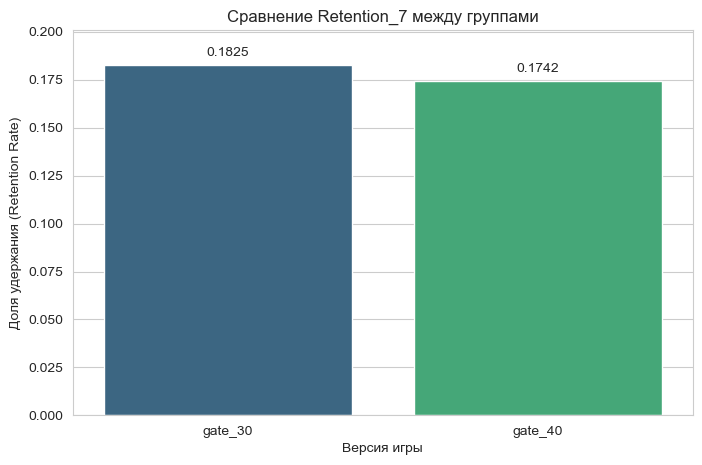

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Группируем данные и вычисляем среднее (долю True) для retention_7
retention_data = df_clean.groupby('version')['retention_7'].mean().reset_index()

# Настройка стиля графика
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Построение столбчатой диаграммы
ax = sns.barplot(data=retention_data, x='version', y='retention_7', palette='viridis')

# Добавление подписей и заголовков
plt.title('Сравнение Retention_7 между группами')
plt.ylabel('Доля удержания (Retention Rate)')
plt.xlabel('Версия игры')

# Добавление значений над столбцами для наглядности
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.ylim(0, retention_data['retention_7'].max() * 1.1) # Автоматический отступ сверху
plt.show()

gate_30 имеет лучшие результаты по сравнению с gate_40 по удержанию после 7-го дня после начала игры